# Alloy Multi-Agent Pipeline Analysis\nComparação entre GPT-5 e Gemini 2.5 Flash (com e sem Pós-Processamento).

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

def parse_md_table(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
        
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    # Filter only table lines
    table_lines = [l.strip() for l in lines if l.strip().startswith('|')]
    if not table_lines:
        return None
        
    headers = [h.strip() for h in table_lines[0].split('|')[1:-1]]
    data = []
    for line in table_lines[2:]:
        row = [cell.strip().replace('**', '') for cell in line.split('|')[1:-1]]
        data.append(dict(zip(headers, row)))
        
    df = pd.DataFrame(data)
    # Convert numeric columns
    numeric_cols = ['Tests', 'Syntax', 'Consistent', 'Valid', 'Wrong', 'Misses', 'Cost']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

def get_totals(filepath):
    df = parse_md_table(filepath)
    if df is not None:
        totals = df[df['Requirement'].str.contains('Totals', na=False, case=False)].iloc[-1]
        return totals
    return None

gpt5_md = 'results/gpt-5-2025-08-07_200925_few3.md'
gemini_raw_md = '../data/raw/experiment_raw.md'
gemini_proc_md = '../data/processed/experiment_processed.md'

gpt5_totals = get_totals(gpt5_md)
raw_totals = get_totals(gemini_raw_md)
proc_totals = get_totals(gemini_proc_md)

results = []
if gpt5_totals is not None:
    results.append({'Model': 'GPT-5 (Baseline)', **gpt5_totals.to_dict()})
if raw_totals is not None:
    results.append({'Model': 'Gemini 2.5 (Raw)', **raw_totals.to_dict()})
if proc_totals is not None:
    results.append({'Model': 'Gemini 2.5 (Processed)', **proc_totals.to_dict()})

if not results:
    print("Nenhum dado encontrado!")
else:
    df_results = pd.DataFrame(results)
    display(df_results[['Model', 'Cost', 'Tests', 'Syntax', 'Consistent', 'Valid', 'Wrong', 'Misses']])


,Model,Cost,Tests,Syntax,Consistent,Valid,Wrong,Misses
0,GPT-5 (Baseline),3.56,258,255,255,247,4395.0,525.0
1,Gemini 2.5 (Raw),0.01,398,116,103,93,842.0,431.0
2,Gemini 2.5 (Processed),0.01,398,116,103,93,842.0,431.0


## Métricas Relativas (%)

In [6]:
# Calculate Percentages based on Totals
if 'df_results' in locals():
    df_pct = df_results.copy()
    df_pct['Syntax (%)'] = (df_pct['Syntax'] / df_pct['Tests']) * 100
    df_pct['Consistent (%)'] = (df_pct['Consistent'] / df_pct['Tests']) * 100
    df_pct['Valid (%)'] = (df_pct['Valid'] / df_pct['Tests']) * 100
    df_pct['Missed (%)'] = (df_pct['Misses'] / df_pct['Wrong']) * 100

    display(df_pct[['Model', 'Syntax (%)', 'Consistent (%)', 'Valid (%)', 'Missed (%)']].round(2))


,Model,Syntax (%),Consistent (%),Valid (%),Missed (%)
0,GPT-5 (Baseline),98.84,98.84,95.74,11.95
1,Gemini 2.5 (Raw),29.15,25.88,23.37,51.19
2,Gemini 2.5 (Processed),29.15,25.88,23.37,51.19


## Gráficos de Performance

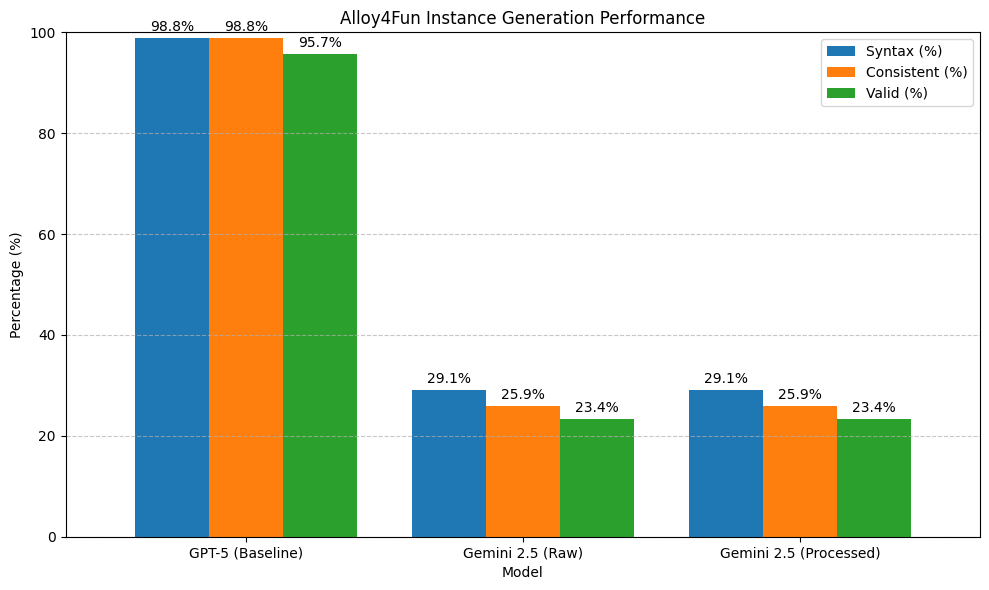

In [7]:
# Plotting the metrics
if 'df_pct' in locals():
    metrics = ['Syntax (%)', 'Consistent (%)', 'Valid (%)']

    df_plot = df_pct.set_index('Model')[metrics]

    ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.8)
    plt.title('Alloy4Fun Instance Generation Performance')
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add values on top of bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

    plt.tight_layout()
    plt.show()


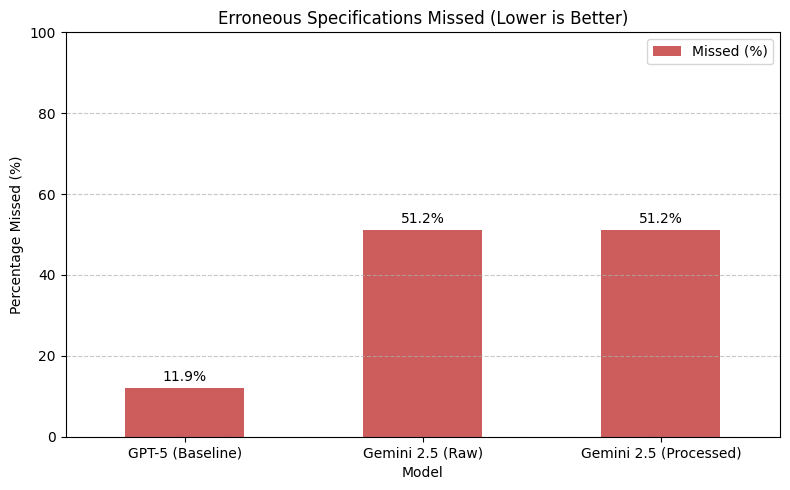

In [8]:
# Missed Specifications Plot (Lower is better)
if 'df_pct' in locals():
    ax = df_pct.set_index('Model')[['Missed (%)']].plot(kind='bar', figsize=(8, 5), color='indianred')
    plt.title('Erroneous Specifications Missed (Lower is Better)')
    plt.ylabel('Percentage Missed (%)')
    plt.ylim(0, 100)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points')

    plt.tight_layout()
    plt.show()
